Opened: True
Total frames: 208
Processed frames: 208


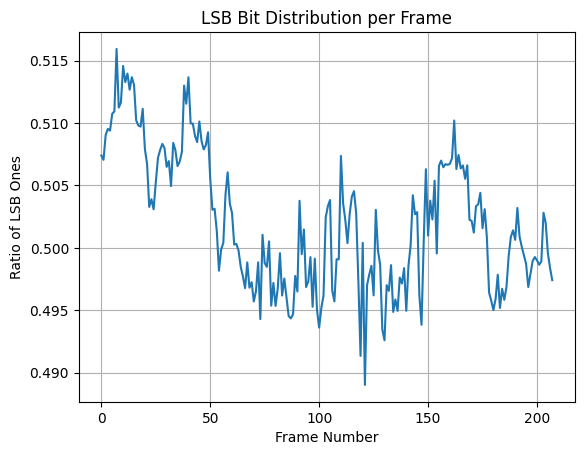

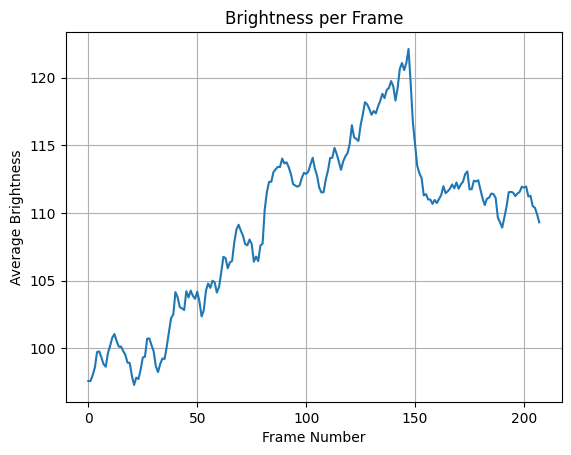

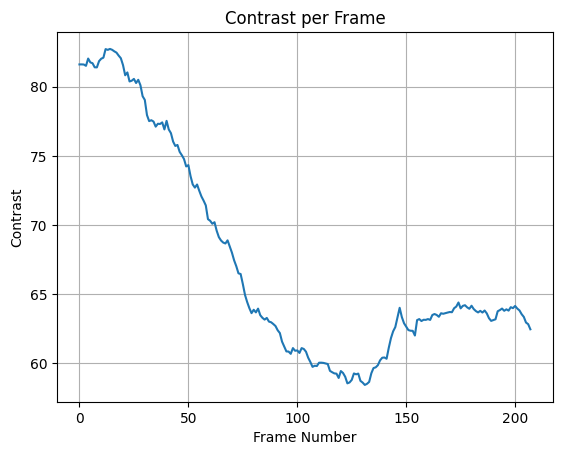

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

video_path = r"C:\Users\yasse\Downloads\VideoSteganography_COE (2)\VideoSteganography_COE\input.mp4"

cap = cv2.VideoCapture(video_path)

print("Opened:", cap.isOpened())
print("Total frames:", int(cap.get(cv2.CAP_PROP_FRAME_COUNT)))

if not cap.isOpened():
    raise Exception("Video did not open. Check the path or filename.")

frame_numbers = []
lsb_ones_ratio = []
brightness_values = []
contrast_values = []

frame_index = 0

while True:
    ret, frame = cap.read()

    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    lsb = gray & 1
    ones_ratio = np.mean(lsb)

    brightness = np.mean(gray)
    contrast = np.std(gray)

    frame_numbers.append(frame_index)
    lsb_ones_ratio.append(ones_ratio)
    brightness_values.append(brightness)
    contrast_values.append(contrast)

    frame_index += 1

cap.release()

print("Processed frames:", len(frame_numbers))

plt.figure()
plt.plot(frame_numbers, lsb_ones_ratio)
plt.title("LSB Bit Distribution per Frame")
plt.xlabel("Frame Number")
plt.ylabel("Ratio of LSB Ones")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(frame_numbers, brightness_values)
plt.title("Brightness per Frame")
plt.xlabel("Frame Number")
plt.ylabel("Average Brightness")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(frame_numbers, contrast_values)
plt.title("Contrast per Frame")
plt.xlabel("Frame Number")
plt.ylabel("Contrast")
plt.grid(True)
plt.show()